## 1.0 use pth model to predict the test set

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # optional, not used below but ok to keep

# --- 1. setup environment ---
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# --- 2. get model ---
from utils.cnn import CNN
from utils.normalizer import Normalizer

pretrain_weight_path = './work_dirs/epoch_099_12135.pth'
model = CNN().to(device)
ckpt = torch.load(pretrain_weight_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'], strict=True)
model.eval()
print("Loaded model from:", pretrain_weight_path)

# --- 3. setup normalizer (optional, currently not applied) ---
normalizer = Normalizer()
normalizer.load("./combined_output_12135_train_normalizer.pt")
print("Loaded normalizer from: ./combined_output_12135_train_normalizer.pt")

# --- 4. prepare input ---
# Load the slices, e.g. shape (375, 20, 20, 20)
arr = np.load('realizations_3dirs_12135_test.npy')
print("Original arr shape:", arr.shape)


# --- 5. Prepare output folder ---
os.makedirs('predictions_12135', exist_ok=True)

# Lab‐result column names
lab_labels = ['plastic_strain', 'pore_pressure', 'soil_strength', 'volumetric_strain']

# --- 6. Loop over all samples, predict, save CSV ---
for sample in range(arr.shape[0]):
    # slice out (1,1,20,20,20)
    data = torch.from_numpy(arr[sample:sample+1]).float().to(device)

    with torch.no_grad():
        pred = model(data)          # shape (1, 4, 65) or (1, 4, 66) depending on your model
        # If you want de-normalized outputs, uncomment the next line:
        # pred = normalizer.inverse_transform(pred)

        pred = pred.cpu()
        pred_np = pred.numpy()[0]   # (4, 65)

    # Turn into a DataFrame (65 rows × 4 cols)
    df = pd.DataFrame(pred_np.T, columns=lab_labels)

    # Write CSV
    csv_path = f'predictions_12135/sample_{sample:03d}.csv'
    df.to_csv(csv_path, index=False)

    if sample % 10 == 0:
        print(f"Saved {csv_path}")

print("Done saving all CSVs.")


Using device: cuda
Loaded model from: ./work_dirs/epoch_099_12135.pth
Loaded normalizer from: ./combined_output_12135_train_normalizer.pt
Original arr shape: (375, 1, 20, 20, 20)
Saved predictions_12135/sample_000.csv
Saved predictions_12135/sample_010.csv
Saved predictions_12135/sample_020.csv
Saved predictions_12135/sample_030.csv
Saved predictions_12135/sample_040.csv
Saved predictions_12135/sample_050.csv
Saved predictions_12135/sample_060.csv
Saved predictions_12135/sample_070.csv
Saved predictions_12135/sample_080.csv
Saved predictions_12135/sample_090.csv
Saved predictions_12135/sample_100.csv
Saved predictions_12135/sample_110.csv
Saved predictions_12135/sample_120.csv
Saved predictions_12135/sample_130.csv
Saved predictions_12135/sample_140.csv
Saved predictions_12135/sample_150.csv
Saved predictions_12135/sample_160.csv
Saved predictions_12135/sample_170.csv
Saved predictions_12135/sample_180.csv
Saved predictions_12135/sample_190.csv
Saved predictions_12135/sample_200.csv
Sa

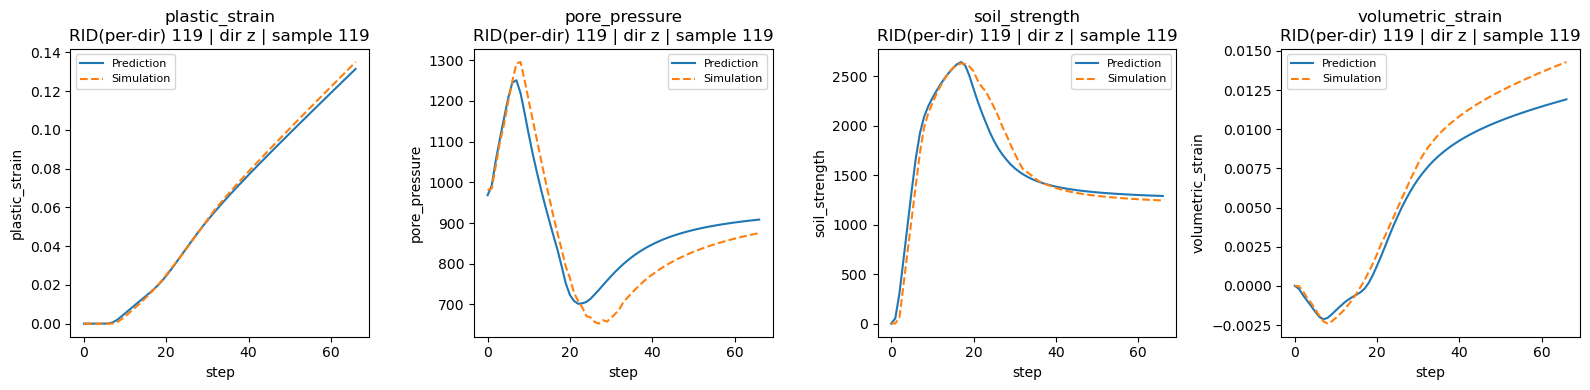

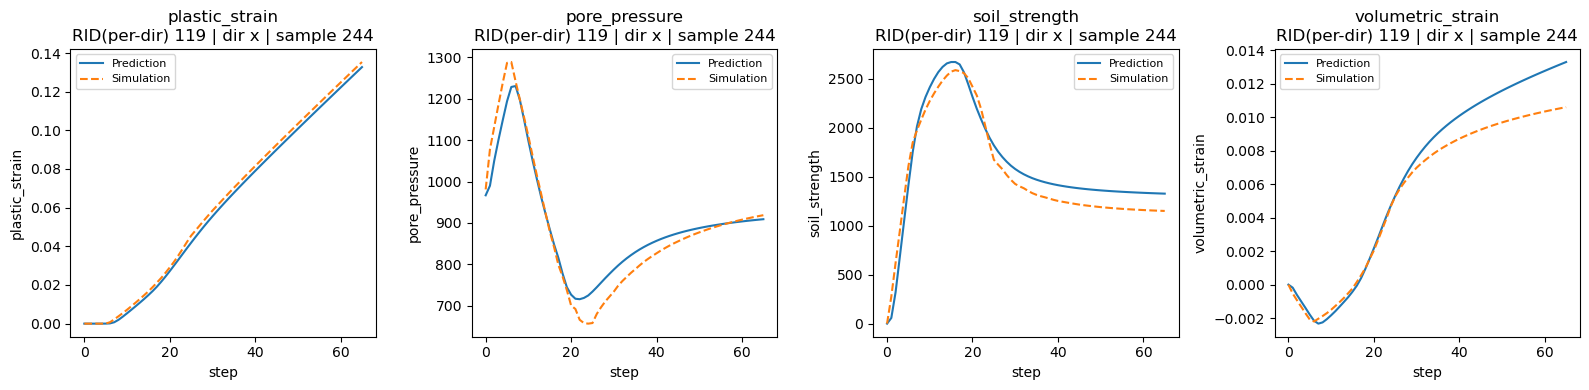

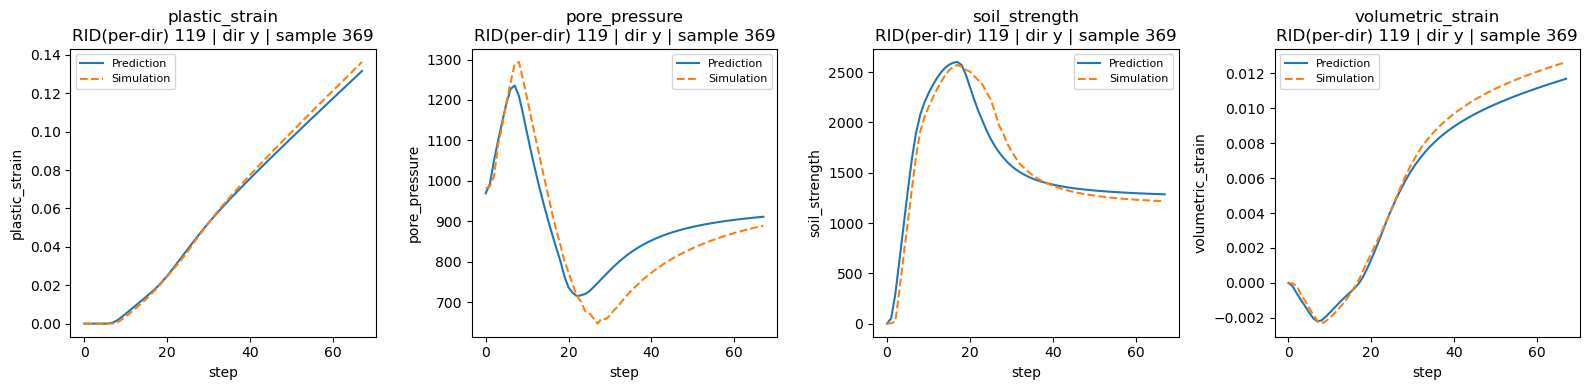

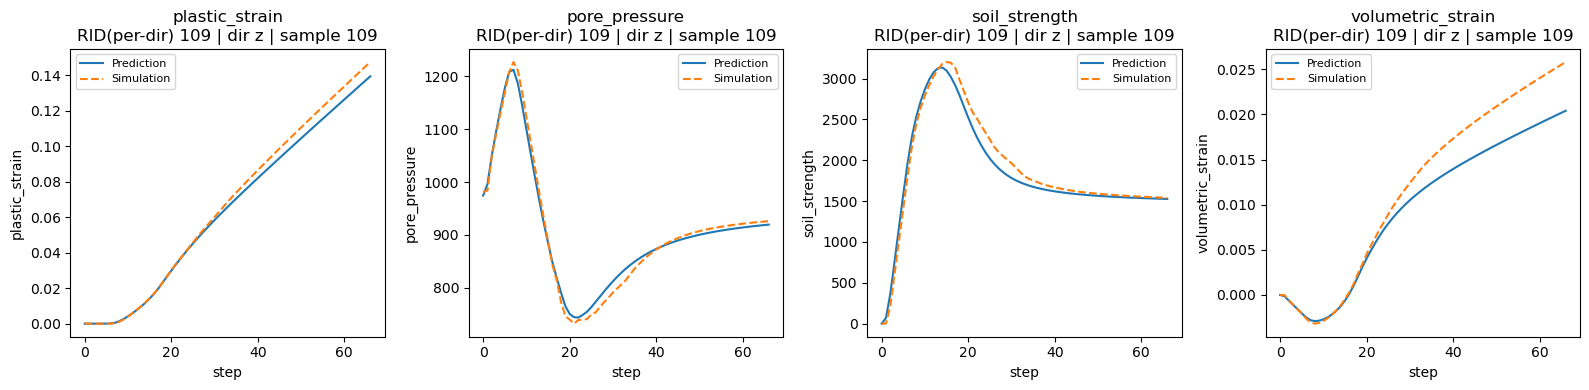

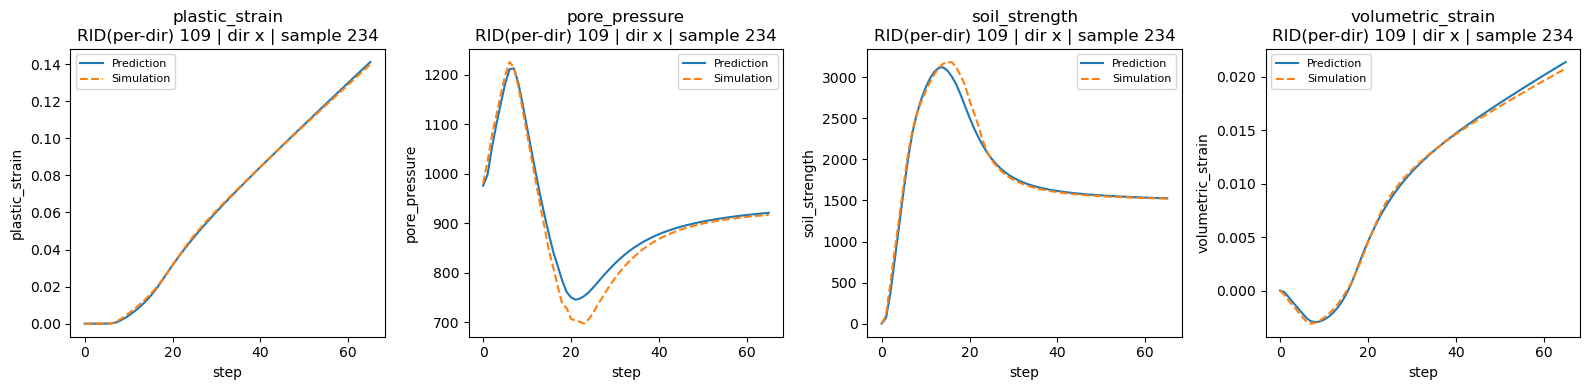

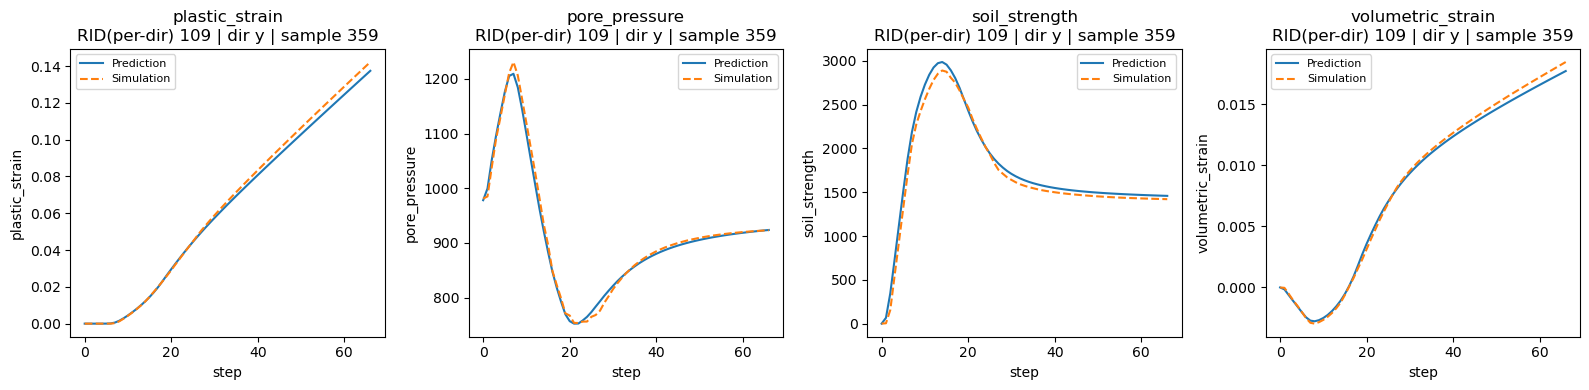

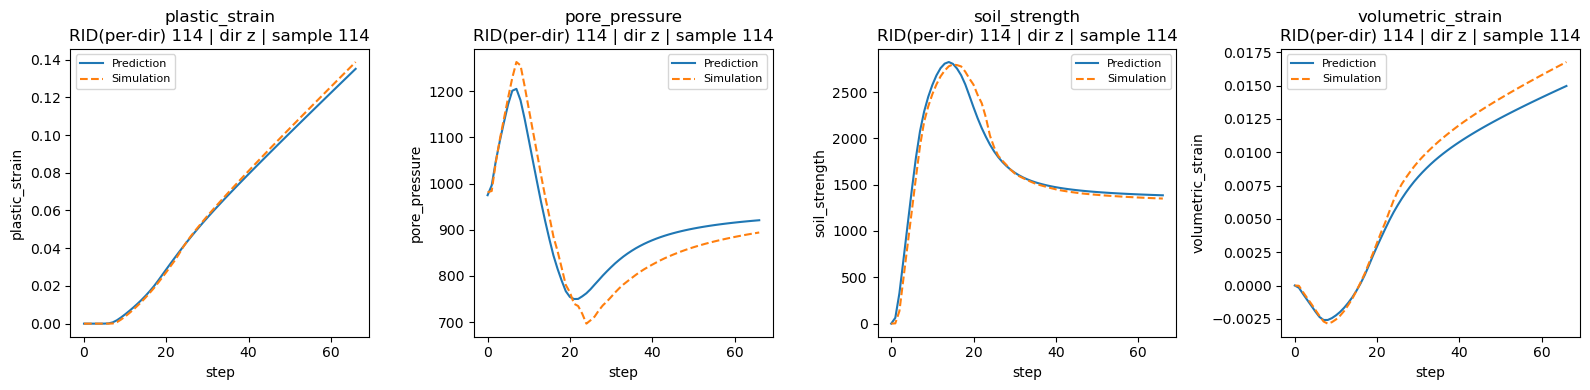

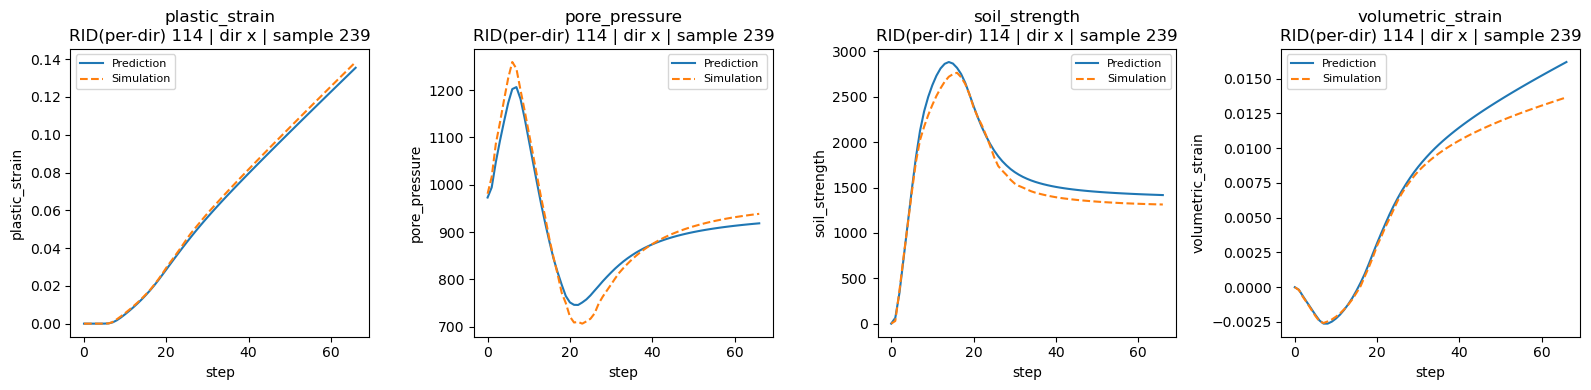

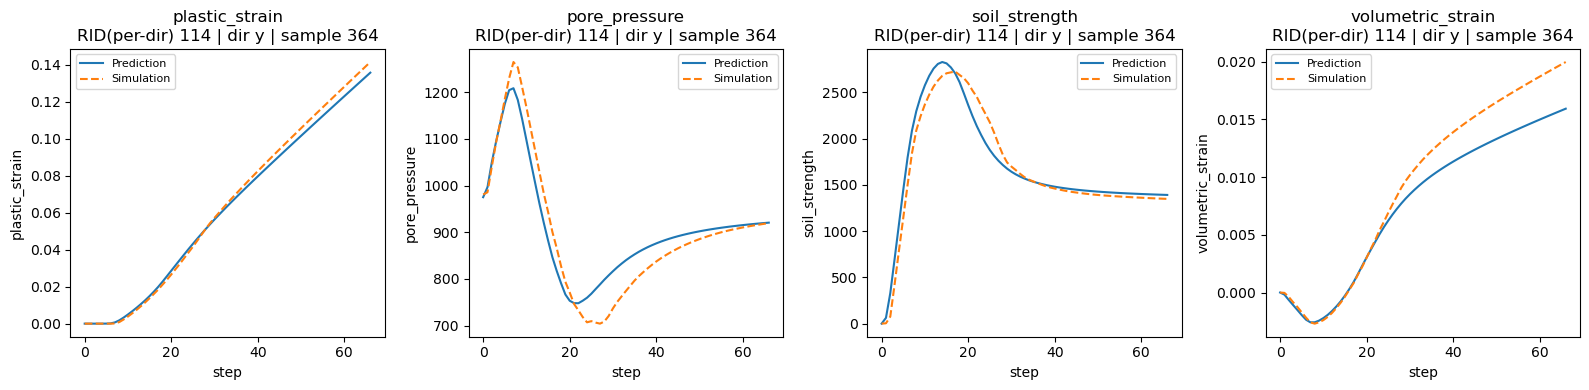

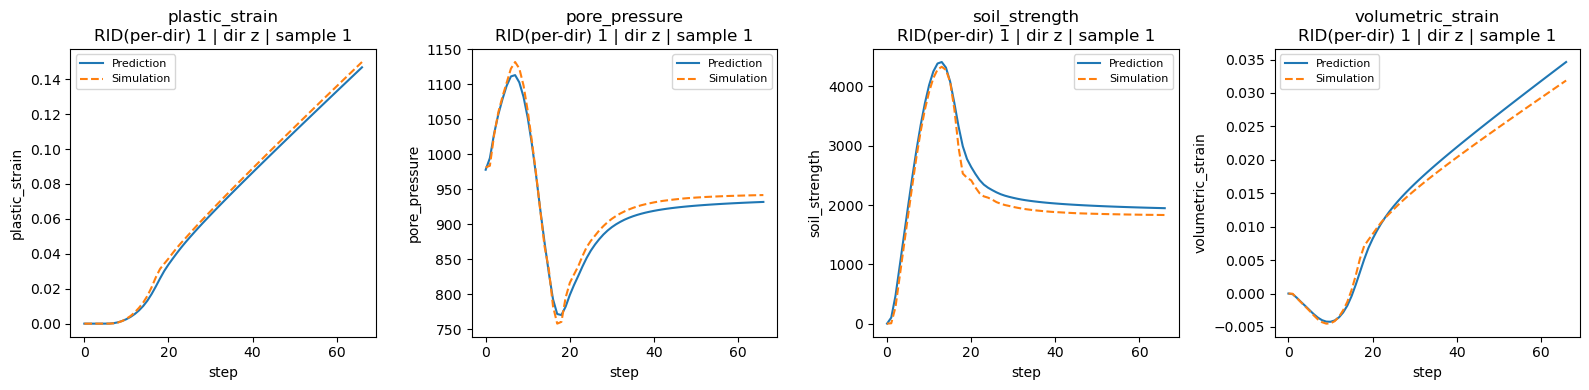

Saved plots to comparison_plots


In [1]:
# ==== Overlay plotter (idx 125 -> x realization_0) with PP first-point fix ====

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- EDIT ----------
PRED_DIR  = "predictions_12135"                  # sample_000.csv ... sample_374.csv
SIM_DIR   = r"C:\Users\xo\CNN_3D_python\20251104_modelprediction\1x1x1 fine model run all"     # ss_{d}_{feat}_table_realization_{rid}.tab
IDX_LIST  = [119, 244, 369, 109, 234, 359, 114,239,364,1]
OUT_DIR   = "comparison_plots"
SHOW      = True
PAD_WIDTH = 3

# Pore-pressure first point override:
APPLY_PP_FIX       = True     # turn on/off the fix
TARGET_PP0         = 981.0    # set y_true[0] for pore pressure
PP0_ONLY_IF_ZERO   = True     # only change if the first value is ~0
PP0_ZERO_TOL       = 1e-6     # "zero" tolerance
# --------------------------

DISPLAY = [
    ("ps",  "plastic_strain"),
    ("pp",  "pore_pressure"),
    ("qa",  "soil_strength"),
    ("vol", "volumetric_strain"),
]
NAME_TO_FEAT = {
    "plastic_strain": "ps",
    "pore_pressure": "pp",
    "soil_strength": "qa",
    "volumetric_strain": "vol",
}

def idx_to_dir(idx: int) -> str:
    if 0 <= idx <= 124:   return "z"
    if 125 <= idx <= 249: return "x"
    if 250 <= idx <= 374: return "y"
    raise ValueError("idx must be in 0..374")

def per_dir_rid(idx: int) -> int:
    """Map global idx to per-direction realization id (0..124)."""
    return idx % 125

# ---------- predictions: sample_000.csv with 4 named columns ----------
def load_prediction(pred_root: Path, idx: int, pad_width: int = PAD_WIDTH):
    p = pred_root / f"sample_{idx:0{pad_width}d}.csv"
    if not p.exists():
        p = pred_root / f"sample_{idx}.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing prediction file: {p}")
    df = pd.read_csv(p)
    norm = {c: c.strip().lower() for c in df.columns}
    inv  = {v: k for k, v in norm.items()}
    return {
        "ps":  df[inv["plastic_strain"]].to_numpy(float),
        "pp":  df[inv["pore_pressure"]].to_numpy(float),
        "qa":  df[inv["soil_strength"]].to_numpy(float),
        "vol": df[inv["volumetric_strain"]].to_numpy(float),
    }

# ---------- simulations: .tab/.csv; ignore axial strain, use value col ----------
def _read_table_loose(path: Path):
    try:
        return pd.read_csv(path, sep=r"\s+", engine="python")
    except Exception:
        return pd.read_csv(path)

def load_sim_series(sim_root: Path, d: str, feat: str, rid_dir: int):
    """Open ss_{d}_{feat}_table_realization_{rid_dir}.tab (or .csv).
       Return value series (2nd numeric column)."""
    tab = sim_root / f"ss_{d}_{feat}_table_realization_{rid_dir}.tab"
    csv = sim_root / f"ss_{d}_{feat}_table_realization_{rid_dir}.csv"
    if tab.exists():
        df = _read_table_loose(tab); used = tab
    elif csv.exists():
        df = _read_table_loose(csv); used = csv
    else:
        raise FileNotFoundError(f"No sim file for {d}-{feat} rid={rid_dir}")

    num = df.apply(pd.to_numeric, errors="coerce")
    cols = [c for c in num.columns if num[c].notna().sum() > 0]
    assert len(cols) >= 2, f"{used.name}: need >=2 numeric cols"

    y = num[cols[1]].dropna().to_numpy(float)

    # ---- Optional pore-pressure first-point override ----
    if APPLY_PP_FIX and feat == "pp" and y.size > 0:
        if (not PP0_ONLY_IF_ZERO) or (abs(y[0]) <= PP0_ZERO_TOL):
            y = y.copy()
            y[0] = float(TARGET_PP0)

    return y, used

# ---------- helpers ----------
def resample_to_len(y, target_len):
    y = np.asarray(y).ravel()
    if y.size == target_len: return y
    if y.size == 0:          return np.zeros(target_len)
    if y.size == 1:          return np.full(target_len, y.item())
    x_src = np.linspace(0, 1, y.size)
    x_tgt = np.linspace(0, 1, target_len)
    return np.interp(x_tgt, x_src, y)

# ---------- plotting ----------
def plot_one(idx: int, pred_series: dict, sim_root: Path, out_dir: Path, show: bool):
    d = idx_to_dir(idx)
    rid_dir = per_dir_rid(idx)

    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    for ax, (feat, title) in zip(axs, DISPLAY):
        y_true, used_path = load_sim_series(sim_root, d, feat, rid_dir)
        y_pred = resample_to_len(pred_series[feat], len(y_true))
        steps = np.arange(len(y_true))
        ax.plot(steps, y_pred,  label="Prediction")
        ax.plot(steps, y_true, "--", label="Simulation")
        ax.set_title(f"{title}\nRID(per-dir) {rid_dir} | dir {d} | sample {idx}")
        ax.set_xlabel("step"); ax.set_ylabel(title); ax.legend(fontsize=8)

    fig.tight_layout()
    out = out_dir / f"overlay_sample{idx:03d}_dir{d}_rid{rid_dir}.png"
    fig.savefig(out, dpi=140)
    if show: plt.show()
    plt.close(fig)

# ---------- run ----------
pred_root = Path(PRED_DIR)
sim_root  = Path(SIM_DIR)
out_path  = Path(OUT_DIR); out_path.mkdir(parents=True, exist_ok=True)

for idx in IDX_LIST:
    pred_series = load_prediction(pred_root, idx)
    plot_one(idx, pred_series, sim_root, out_path, SHOW)

print(f"Saved plots to {out_path}")


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- Paths ----
PRED_DIR  = Path("predictions_12135")
SIM_DIR   = Path(r"C:\Users\xo\CNN_3D_python\20251104_modelprediction\1x1x1 fine model run all")
OUT_CSV   = "fit_summary.csv"
PAD_WIDTH = 3

# --- pore-pressure first-point override (match plotting script) ---
APPLY_PP_FIX       = True     # set False to disable
TARGET_PP0         = 981.0    # replace y_true[0] for pp
PP0_ONLY_IF_ZERO   = True     # only if first value ~ 0
PP0_ZERO_TOL       = 1e-6

# ---- Helpers (same mapping as plots) ----
def idx_to_dir(idx):
    if 0 <= idx <= 124: return "z"
    if 125 <= idx <= 249: return "x"
    if 250 <= idx <= 374: return "y"
    raise ValueError("idx out of range")

def per_dir_rid(idx):
    return idx % 125

def load_prediction(idx):
    p = PRED_DIR / f"sample_{idx:0{PAD_WIDTH}d}.csv"
    df = pd.read_csv(p)
    norm = {c: c.strip().lower() for c in df.columns}
    inv = {v: k for k, v in norm.items()}
    return {
        "ps":  df[inv["plastic_strain"]].to_numpy(float),
        "pp":  df[inv["pore_pressure"]].to_numpy(float),
        "qa":  df[inv["soil_strength"]].to_numpy(float),
        "vol": df[inv["volumetric_strain"]].to_numpy(float),
    }

def _read_table_loose(path):
    try:
        return pd.read_csv(path, sep=r"\s+", engine="python")
    except Exception:
        return pd.read_csv(path)

def load_sim_series(d, feat, rid):
    """Load sim series (second numeric column), with pp first-point fix."""
    f = SIM_DIR / f"ss_{d}_{feat}_table_realization_{rid}.tab"
    if not f.exists():
        f = SIM_DIR / f"ss_{d}_{feat}_table_realization_{rid}.csv"
    df = _read_table_loose(f)
    num = df.apply(pd.to_numeric, errors="coerce")
    cols = [c for c in num.columns if num[c].notna().sum() > 0]
    y = num[cols[1]].dropna().to_numpy(float)

    # --- pore-pressure first-point override (identical to plotter) ---
    if APPLY_PP_FIX and feat == "pp" and y.size > 0:
        if (not PP0_ONLY_IF_ZERO) or (abs(y[0]) <= PP0_ZERO_TOL):
            y = y.copy()
            y[0] = float(TARGET_PP0)

    return y

def resample_to_len(y, target_len):
    y = np.asarray(y).ravel()
    if y.size == target_len: return y
    if y.size == 0: return np.zeros(target_len)
    if y.size == 1: return np.full(target_len, y.item())
    x_src = np.linspace(0, 1, y.size)
    x_tgt = np.linspace(0, 1, target_len)
    return np.interp(x_tgt, x_src, y)

# ---- Compute metrics for all samples ----
records = []
for idx in range(375):
    try:
        d = idx_to_dir(idx)
        rid = per_dir_rid(idx)
        pred = load_prediction(idx)
    except Exception as e:
        print(f"[skip {idx}] prediction load error:", e)
        continue

    for feat in ["qa", "vol", "pp", "ps"]:
        try:
            y_true = load_sim_series(d, feat, rid)
            y_pred = resample_to_len(pred[feat], len(y_true))
        except Exception as e:
            print(f"[skip {idx}-{feat}] sim load error:", e)
            continue

        mae  = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        r2_raw = r2_score(y_true, y_pred)

        # --- bias-aware diagnostics ---
        bias = float(np.mean(y_true - y_pred))
        r2_biascorr = r2_score(y_true, y_pred + bias)  # constant-offset corrected
        r2_shape    = r2_score(y_true - y_true.mean(), y_pred - y_pred.mean())  # mean-removed
        nrmse_range = rmse / max(1e-12, (y_true.max() - y_true.min()))  # normalized to range

        records.append(dict(
            idx=idx, dir=d, rid=rid, feat=feat,
            mae=mae, rmse=rmse,
            r2=r2_raw, r2_biascorr=r2_biascorr, r2_shape=r2_shape,
            bias=bias, nrmse_range=nrmse_range
        ))

df = pd.DataFrame(records)
df.to_csv(OUT_CSV, index=False)
print(f"Saved {len(df)} results → {OUT_CSV}")

# ---- Summaries ----
threshold = 0.80
def pct_good(col):  # percentage good by feature for a metric column
    s = (df.assign(good=lambda x: x[col] >= threshold)
           .groupby("feat")["good"]
           .agg(sum="sum", count="count"))
    s["pct_good"] = s["sum"] / s["count"] * 100
    return s

print("\n==== Summary (R²_raw ≥ 0.8 good) ====")
print(pct_good("r2"))

print("\n==== Summary (R²_biascorr ≥ 0.8 good) ====")
print(pct_good("r2_biascorr"))

print("\n==== Summary (R²_shape ≥ 0.8 good) ====")
print(pct_good("r2_shape"))


Saved 1500 results → fit_summary.csv

==== Summary (R²_raw ≥ 0.8 good) ====
      sum  count    pct_good
feat                        
pp    363    375   96.800000
ps    375    375  100.000000
qa    320    375   85.333333
vol   303    375   80.800000

==== Summary (R²_biascorr ≥ 0.8 good) ====
      sum  count    pct_good
feat                        
pp    365    375   97.333333
ps    375    375  100.000000
qa    370    375   98.666667
vol   354    375   94.400000

==== Summary (R²_shape ≥ 0.8 good) ====
      sum  count    pct_good
feat                        
pp    365    375   97.333333
ps    375    375  100.000000
qa    370    375   98.666667
vol   354    375   94.400000


Saved 375 rows → qa_peaks_375.csv

== Peak qa (TRUE) distribution on 375 samples ==
        bucket  count       pct
   high(>4000)    232 61.866667
mid(2500-4000)    143 38.133333


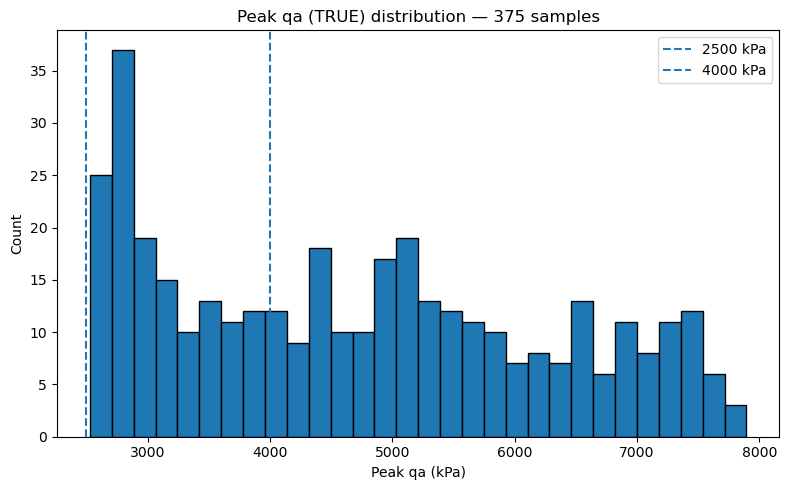

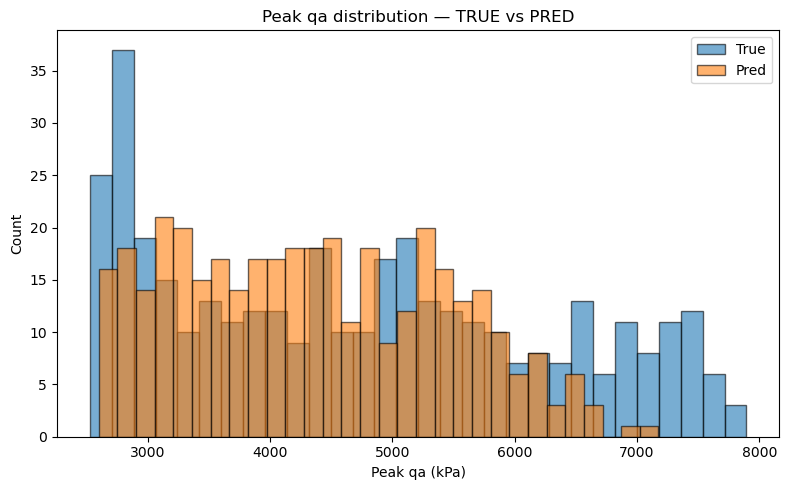

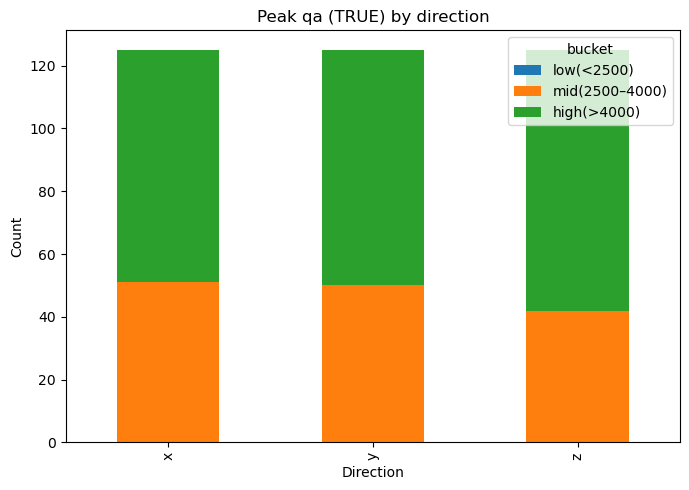

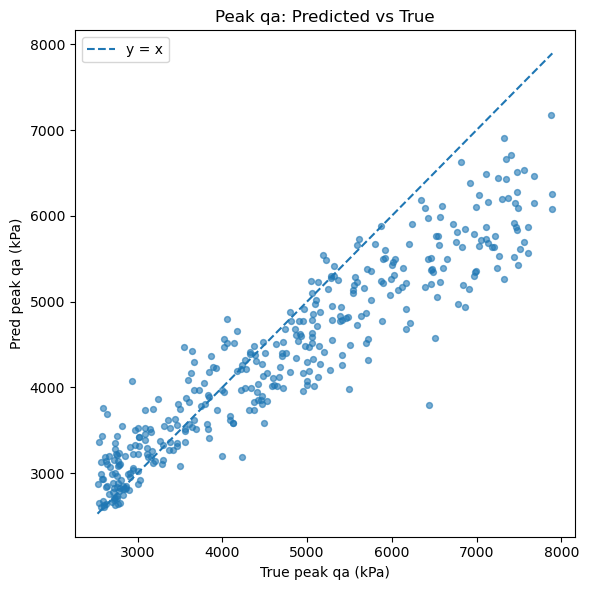

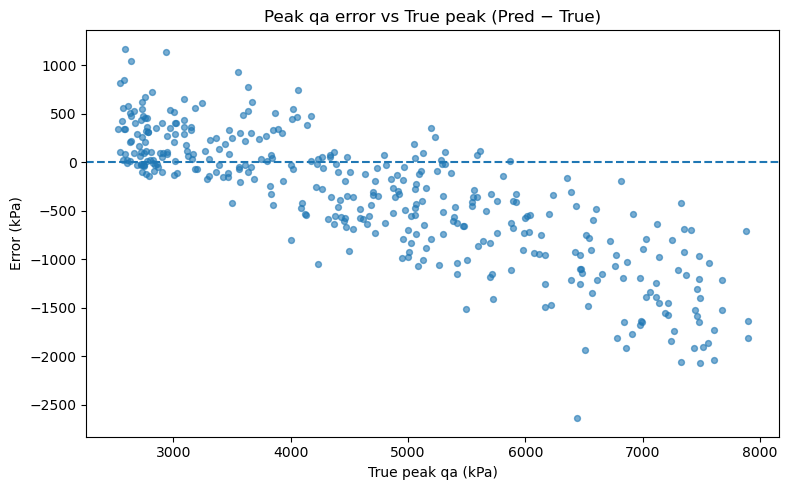

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# ---- Peak qa collection (true vs predicted) ----
qa_peak_rows = []

for idx in range(375):
    try:
        d   = idx_to_dir(idx)
        rid = per_dir_rid(idx)
        pred = load_prediction(idx)  # dict with 'qa', 'vol', 'pp', 'ps'
    except Exception as e:
        print(f"[skip {idx}] prediction load error:", e)
        continue

    # only need qa here
    try:
        y_true_qa = load_sim_series(d, "qa", rid)                 # array len L_true
        y_pred_qa = resample_to_len(pred["qa"], len(y_true_qa))   # match length
    except Exception as e:
        print(f"[skip {idx}-qa] sim load error:", e)
        continue

    qa_peak_rows.append({
        "idx": idx,
        "dir": d,
        "rid": rid,
        "qa_peak_true": float(np.max(y_true_qa)),
        "qa_peak_pred": float(np.max(y_pred_qa)),
        "qa_len_true": int(len(y_true_qa)),
    })

import pandas as pd, numpy as np
df_peaks = pd.DataFrame(qa_peak_rows)
df_peaks.to_csv("qa_peaks_375.csv", index=False)
print(f"Saved {len(df_peaks)} rows → qa_peaks_375.csv")

# thresholds (adjust if you like)
LOW_THR  = 2500
HIGH_THR = 4000

def bucketize(x):
    if x < LOW_THR:      return "low(<2500)"
    elif x <= HIGH_THR:  return "mid(2500-4000)"
    else:                return "high(>4000)"

df_peaks["bucket_true"] = df_peaks["qa_peak_true"].apply(bucketize)
dist = (df_peaks["bucket_true"]
        .value_counts()
        .rename_axis("bucket")
        .reset_index(name="count")
        .sort_values("bucket"))

dist["pct"] = dist["count"] / len(df_peaks) * 100
print("\n== Peak qa (TRUE) distribution on 375 samples ==")
print(dist.to_string(index=False))




# thresholds (same as before—tweak if you like)
LOW_THR  = 2500
HIGH_THR = 4000

def bucketize(x):
    if x < LOW_THR:      return "low(<2500)"
    elif x <= HIGH_THR:  return "mid(2500–4000)"
    else:                return "high(>4000)"

# Ensure buckets exist
df_peaks["bucket_true"] = df_peaks["qa_peak_true"].apply(bucketize)
df_peaks["bucket_pred"] = df_peaks["qa_peak_pred"].apply(bucketize)

# 1) Histogram of TRUE peak qa
plt.figure(figsize=(8,5))
plt.hist(df_peaks["qa_peak_true"], bins=30, edgecolor="black")
plt.axvline(LOW_THR,  linestyle="--", label=f"{LOW_THR} kPa")
plt.axvline(HIGH_THR, linestyle="--", label=f"{HIGH_THR} kPa")
plt.title("Peak qa (TRUE) distribution — 375 samples")
plt.xlabel("Peak qa (kPa)"); plt.ylabel("Count"); plt.legend()
plt.tight_layout(); plt.show()

# 2) TRUE vs PRED peak qa (overlaid histograms)
plt.figure(figsize=(8,5))
plt.hist(df_peaks["qa_peak_true"], bins=30, alpha=0.6, label="True", edgecolor="black")
plt.hist(df_peaks["qa_peak_pred"], bins=30, alpha=0.6, label="Pred", edgecolor="black")
plt.title("Peak qa distribution — TRUE vs PRED")
plt.xlabel("Peak qa (kPa)"); plt.ylabel("Count"); plt.legend()
plt.tight_layout(); plt.show()

# 3) By-direction stacked bars (TRUE)
by_dir = (df_peaks
          .assign(bucket=df_peaks["qa_peak_true"].apply(bucketize))
          .groupby(["dir","bucket"]).size().unstack(fill_value=0)
          .reindex(columns=["low(<2500)","mid(2500–4000)","high(>4000)"], fill_value=0))
by_dir.plot(kind="bar", stacked=True, figsize=(7,5))
plt.title("Peak qa (TRUE) by direction")
plt.xlabel("Direction"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

# 4) Scatter: TRUE peak vs PRED peak (with y=x)
plt.figure(figsize=(6,6))
x = df_peaks["qa_peak_true"].to_numpy()
y = df_peaks["qa_peak_pred"].to_numpy()
plt.scatter(x, y, s=18, alpha=0.6)
mn, mx = float(np.min(x)), float(np.max(x))
plt.plot([mn, mx], [mn, mx], linestyle="--", label="y = x")
plt.title("Peak qa: Predicted vs True")
plt.xlabel("True peak qa (kPa)"); plt.ylabel("Pred peak qa (kPa)"); plt.legend()
plt.tight_layout(); plt.show()

# 5) Error vs TRUE peak (bias view)
plt.figure(figsize=(8,5))
err = df_peaks["qa_peak_pred"] - df_peaks["qa_peak_true"]
plt.scatter(df_peaks["qa_peak_true"], err, s=18, alpha=0.6)
plt.axhline(0.0, linestyle="--")
plt.title("Peak qa error vs True peak (Pred − True)")
plt.xlabel("True peak qa (kPa)"); plt.ylabel("Error (kPa)")
plt.tight_layout(); plt.show()


cuda
torch.Size([1, 1, 20, 20, 20])
torch.Size([1, 4, 65])


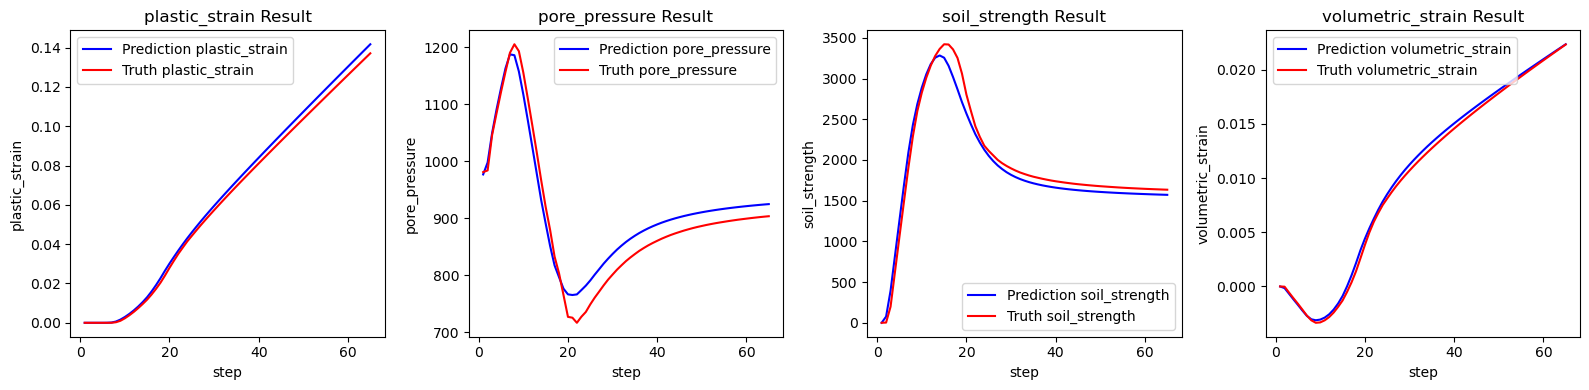

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils.cnn import CNN
from utils.lploss import LpLoss
from utils.r2 import r2_np, r2_torch

device = torch.device(f'cuda' if torch.cuda.is_available() else 'cpu')#torch.device('cpu')#
print(device)

pretrain_weight_path = "./work_dirs/epoch_099_12135.pth"
model = CNN().to(device)
model.load_state_dict(torch.load(pretrain_weight_path)['model_state_dict'], strict=True)
model.eval()

# Generate axial strain values assuming each test data point starts from 0 and increments by 0.002
axial_strain = np.linspace(1, 65, 65)#np.linspace(0, (66 - 1) * 0.002, 66)

sample = 5
for sample in [24]:#range(42):#
    model_type = ["train","val","test"][2]

    if model_type == "train":
        data = torch.tensor(np.load(train_input_name), dtype=torch.float32)[sample:sample+1,...].to(device)
        truth = torch.tensor(np.load(train_gt_name), dtype=torch.float32)[sample:sample+1,...]
    elif model_type == "val":
        data = torch.tensor(np.load(val_input_name), dtype=torch.float32)[sample:sample+1,...].to(device)
        truth = torch.tensor(np.load(val_gt_name), dtype=torch.float32)[sample:sample+1,...]
    else:
        data = torch.tensor(np.load('realizations_3dirs_12135_test.npy'), dtype=torch.float32)[sample:sample+1,...].to(device)
        truth = torch.tensor(np.load('combined_output_12135_test.npy'), dtype=torch.float32)[sample:sample+1,...]

    print(data.shape)
    print(truth.shape)
    # print(test_data.shape)

    with torch.no_grad():
        prediction = model(data).cpu()
        #prediction = normalizer.inverse_transform(prediction) #mute this raw vs raw

        # Save the DataFrame into a CSV file
        # df = pd.DataFrame(prediction.reshape(4, 66).T, columns=[f"{i}" for i in ['plastic_strain', 'pore_pressure', 'soil_strength', 'volumetric_strain']])
        
        # csv_file_path = f"./test_13_plots/sample_{sample % 14}_{['x','y','z'][sample//14]}.csv"
        # df.to_csv(csv_file_path, index=False)

    fig, axs = plt.subplots(1, 4, figsize=(16, 4))

    # Labels for the lab results
    lab_result_labels = ['plastic_strain', 'pore_pressure', 'soil_strength', 'volumetric_strain']#['x','y','z']#

    # Loop through the 4 lab results and plot each
    for i, ax in enumerate(axs.flatten()):
        # Plot axial strain vs result
        ax.plot(axial_strain, prediction[0,i,...].flatten(), label=f'Prediction {lab_result_labels[i]}', color='blue')
        ax.plot(axial_strain, truth[0,i,...].flatten(), label=f'Truth {lab_result_labels[i]}', color='red')
        ax.set_title(f'{lab_result_labels[i]} Result')
        ax.set_ylabel(f'{lab_result_labels[i]}')
        ax.set_xlabel('step')
        ax.legend()

    plt.tight_layout()
    plt.show()
    # plt.savefig(f"./test_13_plots/sample_{sample % 14}_{['x','y','z'][sample//14]}.png")


In [11]:
import pandas as pd
import numpy as np

# ======================
# REQUIRED FILES
# ======================
fit = pd.read_csv("fit_summary.csv")        # from your metric script
qa_peaks = pd.read_csv("qa_peaks_375.csv")  # THIS new file you shared

# merge the files to get true peak + pred peak
df = fit.merge(qa_peaks, on=["idx", "dir", "rid"], how="inner")

# Use only QA rows
qa = df[df["feat"] == "qa"].copy()

# -------- QUALITY FILTERS --------
PEAK_TOL = 0.10     # 10% peak error tolerance
R2_MIN   = 0.90
NRMSE_MAX= 0.10

qa["peak_err"] = abs(qa["qa_peak_true"] - qa["qa_peak_pred"]) / qa["qa_peak_true"]

good = qa[
    (qa["peak_err"] <= PEAK_TOL) &
    (qa["r2"]       >= R2_MIN) &
    (qa["nrmse_range"] <= NRMSE_MAX)
]

print(f"\nGOOD rows: {len(good)}/{len(qa)} (direction-wise)\n")

# -------- Find realizations good in ALL THREE directions --------
good_rids = []
for rid, g in good.groupby("rid"):
    if {"z","x","y"}.issubset(set(g["dir"])):
        qavg = g["qa_peak_true"].mean()
        good_rids.append((rid, qavg))

good_rids = pd.DataFrame(good_rids, columns=["rid","qa_avg"]).sort_values("qa_avg")

print(f"Valid realizations = {len(good_rids)}\n")

if len(good_rids) == 0:
    print("⚠ No realization qualified — reduce thresholds and try again.")
    quit()

# -------- Select 3 well-spaced samples --------
pos = np.linspace(0, len(good_rids)-1, 5).round().astype(int)
selected = good_rids.iloc[pos]

print("=== SELECTED 3 STRONG SAMPLES (low, mid, high) ===")
print(selected)

# Save details
detail = good.merge(selected, on="rid")
detail.to_csv("selected_5_rids_all_dirs.csv", index=False)
print("\nSaved → selected_5_rids_all_dirs.csv")



GOOD rows: 172/375 (direction-wise)

Valid realizations = 15

=== SELECTED 3 STRONG SAMPLES (low, mid, high) ===
    rid       qa_avg
14  119  2596.806000
2    23  2973.287667
6    39  3805.441333
5    33  4560.615667
9    46  5366.820000

Saved → selected_5_rids_all_dirs.csv


In [12]:
import pandas as pd
import numpy as np

# ======================
# REQUIRED CSVs
# ======================
fit = pd.read_csv("fit_summary.csv")
qa_peaks = pd.read_csv("qa_peaks_375.csv")

# Merge & filter to QA only
df = fit.merge(qa_peaks, on=["idx","dir","rid"], how="inner")
qa = df[df["feat"]=="qa"].copy()

# ----------------- QUALITY FILTERS -----------------
PEAK_TOL = 0.10
R2_MIN   = 0.90
NRMSE_MAX= 0.10

qa["peak_err"] = abs(qa["qa_peak_true"]-qa["qa_peak_pred"])/qa["qa_peak_true"]

good = qa[(qa["peak_err"]<=PEAK_TOL)&
          (qa["r2"]>=R2_MIN)&
          (qa["nrmse_range"]<=NRMSE_MAX)]

print(f"Good curves: {len(good)}/{len(qa)}")

# ----------------- GROUP BY RID --------------------
diverse = []

for rid,g in good.groupby("rid"):
    dirs=set(g["dir"])
    if {"z","x","y"}.issubset(dirs):  # must be good in ALL 3 directions

        peaks=np.array(g.sort_values("dir")["qa_peak_true"])
        pmin,pmax=peaks.min(),peaks.max()

        score = (pmax-pmin)*1.0 + np.std(peaks)*1.0 + (pmax/pmin)*0.5
        
        diverse.append([rid, peaks.mean(), pmin,pmax,score])

div = pd.DataFrame(diverse,columns=["rid","qa_avg","qa_min","qa_max","div_score"])
div = div.sort_values("div_score",ascending=False).reset_index(drop=True)

# ----------------- SELECT TOP 5 MOST DIVERSE -----------------
selected = div.iloc[:5]

print("\n===== 🔥 TOP 5 MOST DIVERSE + GOOD IN ALL DIRECTIONS =====")
print(selected)

detail = good.merge(selected[["rid"]],on="rid")
detail.to_csv("selected_5_diverse_all_dirs.csv",index=False)
print("\nSaved → selected_5_diverse_all_dirs.csv")


Good curves: 172/375

===== 🔥 TOP 5 MOST DIVERSE + GOOD IN ALL DIRECTIONS =====
   rid       qa_avg    qa_min    qa_max    div_score
0  111  5268.687667  4808.661  5755.107  1333.879808
1   13  4115.329333  3608.022  4475.204  1236.858131
2   28  4318.225333  3892.333  4718.954  1165.162561
3   33  4560.615667  4265.592  4952.372   975.960108
4   21  5226.720667  4854.325  5543.113   973.330197

Saved → selected_5_diverse_all_dirs.csv


In [7]:
import pandas as pd
import numpy as np

# ======================
# INPUT FILES
# ======================
fit = pd.read_csv("fit_summary.csv")          # metrics for all feats
qa_peaks = pd.read_csv("qa_peaks_375.csv")    # qa_peak_true / qa_peak_pred

df = fit.merge(qa_peaks, on=["idx", "dir", "rid"], how="inner")
qa = df[df["feat"] == "qa"].copy()

# ======================
# THRESHOLDS (tune)
# ======================
PEAK_TOL   = 0.10
R2_MIN     = 0.90
NRMSE_MAX  = 0.10

TOP_N = None   # set e.g. 20 if you only want best 20; set None to keep all

# ======================
# FILTER "GOOD" ROWS
# ======================
qa["peak_err"] = np.abs(qa["qa_peak_true"] - qa["qa_peak_pred"]) / np.maximum(1e-12, qa["qa_peak_true"])

good = qa[
    (qa["peak_err"] <= PEAK_TOL) &
    (qa["r2"] >= R2_MIN) &
    (qa["nrmse_range"] <= NRMSE_MAX)
].copy()

print(f"GOOD QA rows: {len(good)}/{len(qa)} (direction-wise)")

# ======================
# KEEP ONLY RIDs GOOD IN ALL 3 DIRS
# ======================
need_dirs = {"x", "y", "z"}

# rids that satisfy all 3 dirs
ok_rids = (
    good.groupby("rid")["dir"]
        .apply(lambda s: need_dirs.issubset(set(s)))
)

ok_rids = ok_rids[ok_rids].index.tolist()
print(f"Realizations good in all x/y/z: {len(ok_rids)}")

if len(ok_rids) == 0:
    print("⚠ None qualified. Relax PEAK_TOL / R2_MIN / NRMSE_MAX.")
    raise SystemExit

good3 = good[good["rid"].isin(ok_rids)].copy()

# ======================
# BUILD SUMMARY (rid + idx per dir + mean metrics)
# ======================
# idx mapping per direction
idx_map = (good3.pivot_table(index="rid", columns="dir", values="idx", aggfunc="first")
                .rename(columns={"x":"idx_x", "y":"idx_y", "z":"idx_z"}))

# mean quality stats across dirs
agg = (good3.groupby("rid")
           .agg(
               r2_mean=("r2", "mean"),
               peak_err_mean=("peak_err", "mean"),
               nrmse_mean=("nrmse_range", "mean"),
               qa_peak_true_mean=("qa_peak_true", "mean"),
               qa_peak_pred_mean=("qa_peak_pred", "mean"),
           ))

summary = idx_map.join(agg).reset_index()

# A simple quality score (higher is better):
# prioritize high r2 and low peak_err / nrmse
summary["score"] = summary["r2_mean"] - 0.5*summary["peak_err_mean"] - 0.5*summary["nrmse_mean"]

# Sort best first
summary = summary.sort_values("score", ascending=False).reset_index(drop=True)

# Optionally keep only top N
if TOP_N is not None:
    summary = summary.head(TOP_N)

print("\n=== Selected realizations (best first) ===")
print(summary[["rid", "idx_z", "idx_x", "idx_y", "r2_mean", "peak_err_mean", "nrmse_mean", "score"]].head(30))

# Save outputs
summary.to_csv("good_rids_all_dirs_summary.csv", index=False)

# Also save detail rows (one per rid-dir)
detail_cols = ["rid","dir","idx","qa_peak_true","qa_peak_pred","peak_err","r2","nrmse_range","rmse","mae","bias"]
detail = good3.merge(summary[["rid"]], on="rid", how="inner")[detail_cols].sort_values(["rid","dir"])
detail.to_csv("good_rids_all_dirs_detail.csv", index=False)

print("\nSaved:")
print("  good_rids_all_dirs_summary.csv")
print("  good_rids_all_dirs_detail.csv")


GOOD QA rows: 172/375 (direction-wise)
Realizations good in all x/y/z: 15

=== Selected realizations (best first) ===
    rid  idx_z  idx_x  idx_y   r2_mean  peak_err_mean  nrmse_mean     score
0   109    109    234    359  0.980284       0.024826    0.029642  0.953050
1    40     40    165    290  0.971324       0.026315    0.035223  0.940555
2    23     23    148    273  0.963878       0.027222    0.038887  0.930824
3    13     13    138    263  0.971864       0.050431    0.033032  0.930133
4    45     45    170    295  0.955937       0.010602    0.045155  0.928058
5    21     21    146    271  0.963851       0.037904    0.036994  0.926402
6   114    114    239    364  0.961641       0.030152    0.043094  0.925018
7    39     39    164    289  0.962242       0.038048    0.038480  0.923978
8    33     33    158    283  0.963190       0.047446    0.035487  0.921723
9   111    111    236    361  0.945433       0.031013    0.044089  0.907882
10   31     31    156    281  0.957435       0